In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sys

print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print("\nAll libraries loaded successfully.")

Python version: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:16:45) [MSC v.1942 64 bit (AMD64)]
NumPy version: 2.4.3
SciPy version: 1.17.1
Matplotlib version: 3.10.8

All libraries loaded successfully.


Arm length from hardpoints: 401.1 mm
Specified arm length:        400.0 mm


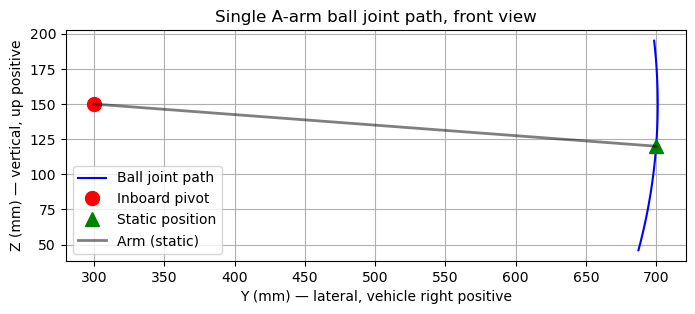

In [2]:
# Simulate a single A-arm pivoting through its arc of travel.
# This is the simplest possible kinematic model:
# one rigid link, pivoting around a fixed inboard axis,
# outboard end traces a circle.

# Inputs (all in meters, SI throughout)
inboard_pivot = np.array([0.0, 0.300, 0.150])  # x, y, z
arm_length = 0.400                              # 400 mm from pivot to ball joint
static_ball_joint = np.array([0.0, 0.700, 0.120])  # where the ball joint sits at ride height

# Verify our static position is consistent with the arm length
# (small sanity check - catches typos in hardpoint entry)
static_length = np.linalg.norm(static_ball_joint - inboard_pivot)
print(f"Arm length from hardpoints: {static_length*1000:.1f} mm")
print(f"Specified arm length:        {arm_length*1000:.1f} mm")

# Sweep the arm through +/- 3 inches of wheel travel
# At 400mm arm length, that's roughly +/- 11 degrees of swing
travel_range_mm = np.linspace(-75, 75, 31)  # 31 points from -75mm to +75mm
angles_rad = travel_range_mm / 1000 / arm_length  # small angle: travel ≈ L*theta

# Compute ball joint position at each angle
# Arm swings in the y-z plane (front view), about the x-axis through the pivot
ball_joint_positions = []
for theta in angles_rad:
    # Rotation matrix about x-axis
    dy = (static_ball_joint[1] - inboard_pivot[1]) * np.cos(theta) - (static_ball_joint[2] - inboard_pivot[2]) * np.sin(theta)
    dz = (static_ball_joint[1] - inboard_pivot[1]) * np.sin(theta) + (static_ball_joint[2] - inboard_pivot[2]) * np.cos(theta)
    ball_joint_positions.append([inboard_pivot[0], inboard_pivot[1] + dy, inboard_pivot[2] + dz])

ball_joint_positions = np.array(ball_joint_positions)

# Plot the arc the ball joint traces, viewed from the front (y-z plane)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ball_joint_positions[:, 1] * 1000, ball_joint_positions[:, 2] * 1000, 'b-', label='Ball joint path')
ax.plot(inboard_pivot[1] * 1000, inboard_pivot[2] * 1000, 'ro', markersize=10, label='Inboard pivot')
ax.plot(static_ball_joint[1] * 1000, static_ball_joint[2] * 1000, 'g^', markersize=10, label='Static position')

# Draw the arm at static position
ax.plot([inboard_pivot[1] * 1000, static_ball_joint[1] * 1000],
        [inboard_pivot[2] * 1000, static_ball_joint[2] * 1000],
        'k-', linewidth=2, alpha=0.5, label='Arm (static)')

ax.set_xlabel('Y (mm) — lateral, vehicle right positive')
ax.set_ylabel('Z (mm) — vertical, up positive')
ax.set_title('Single A-arm ball joint path, front view')
ax.legend()
ax.grid(True)
ax.set_aspect('equal')
plt.show()